# Perceptron -- UCI Bank Marketing

This notebook trains the classic Rosenblatt perceptron on the UCI Bank Marketing dataset to
predict term-deposit subscription from demographic, financial, and prior-contact features.

- Train a perceptron and evaluate its binary classification accuracy
- Plot a learning curve (accuracy vs. epoch) to observe convergence
- Compare how the learning rate affects final accuracy and weight magnitude
- Visualise the linear decision boundary in 2-D PCA space

## Mathematical Intuition

The perceptron predicts using the sign of a linear function:

$$\hat{y} = \operatorname{sign}(\mathbf{w}^\top \mathbf{x} + b)$$

with class labels mapped internally to $\{-1, +1\}$. Training proceeds online: for each
training sample $(\mathbf{x}_i, y_i)$, if the prediction is wrong then

$$\mathbf{w} \leftarrow \mathbf{w} + \eta \, y_i \, \mathbf{x}_i,
\qquad b \leftarrow b + \eta \, y_i$$

and otherwise nothing changes. The **Perceptron Convergence Theorem** guarantees that this
update rule converges in a finite number of updates **if** the data are linearly separable.
On non-separable data, updates continue indefinitely; the learned hyperplane is whatever the
algorithm happened to hold when the maximum number of epochs is reached.

## Dataset Overview

**Source:** UCI Bank Marketing (`fetch_ucirepo(id=222)`) | **Rows used:** 5,000 (subsampled
because the perceptron processes one sample per inner-loop iteration in pure Python) |
**Target:** `y` -- did the client subscribe a term deposit? (yes/no)

The `duration` variable (call length) is dropped because its value is only known after the
call has ended; including it would leak the outcome into the predictors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from ucimlrepo import fetch_ucirepo
from mlpackage import (
    Perceptron, PCA,
    StandardScaler, train_test_split,
    classification_report,
)

bank = fetch_ucirepo(id=222)
df   = bank.data.features.copy()
tgt  = bank.data.targets.copy()

if "duration" in df.columns:
    df = df.drop(columns=["duration"])

combined        = df.copy()
combined["y"]   = tgt.values.ravel()
combined        = combined.sample(n=5000, random_state=42).reset_index(drop=True)

print(f"Shape: {combined.shape}")
print(f"Columns: {list(combined.columns)}")

Shape: (5000, 16)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


## Exploratory Data Analysis

y
no     4407
yes     593
Name: count, dtype: int64
Positive rate: 0.1186


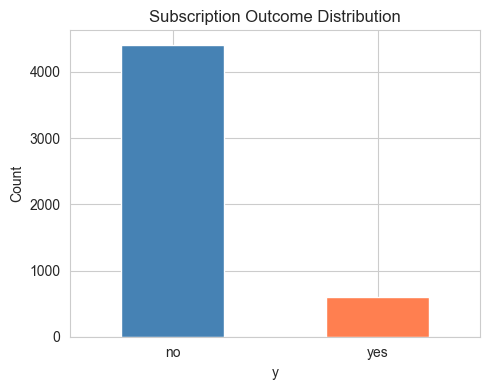

In [2]:
print(combined["y"].value_counts())
print(f"Positive rate: {(combined['y'] == 'yes').mean():.4f}")

plt.figure(figsize=(5, 4))
combined["y"].value_counts().plot(kind="bar", color=["steelblue", "coral"])
plt.title("Subscription Outcome Distribution")
plt.ylabel("Count")
plt.xlabel("y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Numeric columns: ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous']


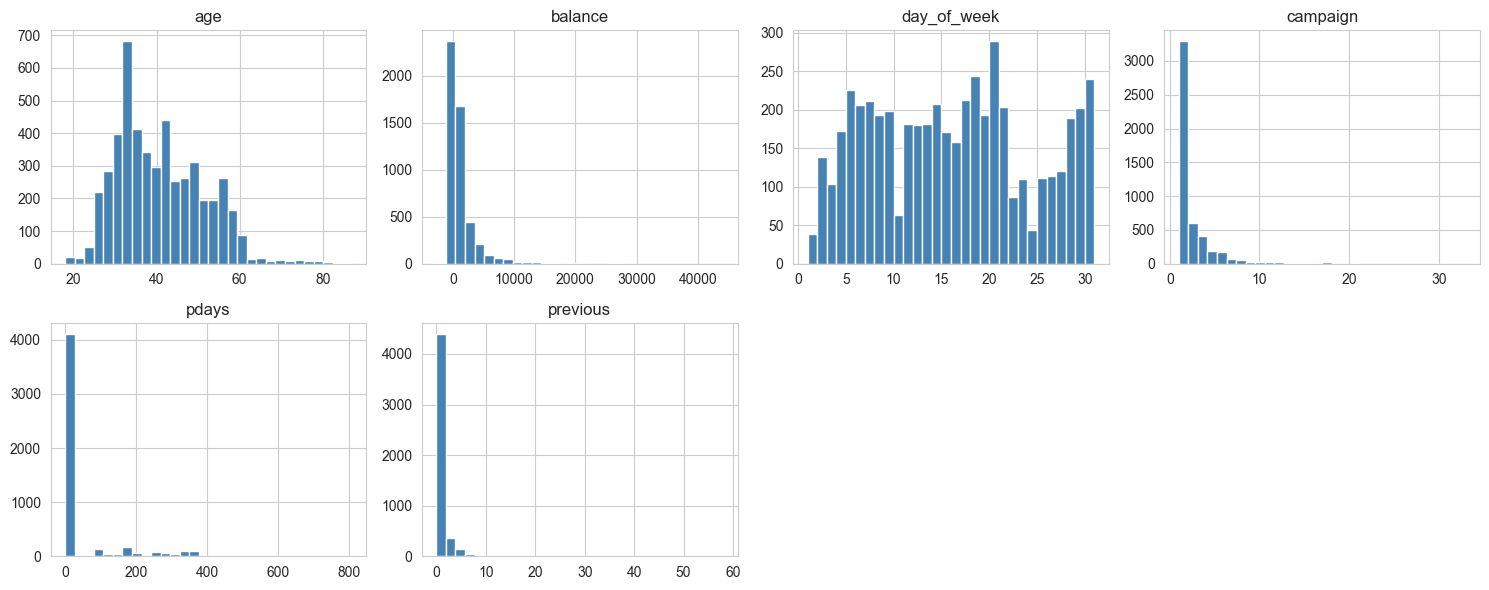

In [3]:
numeric_cols = combined.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

n_num = len(numeric_cols)
n_cols = 4
n_rows = (n_num + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(combined[col], bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

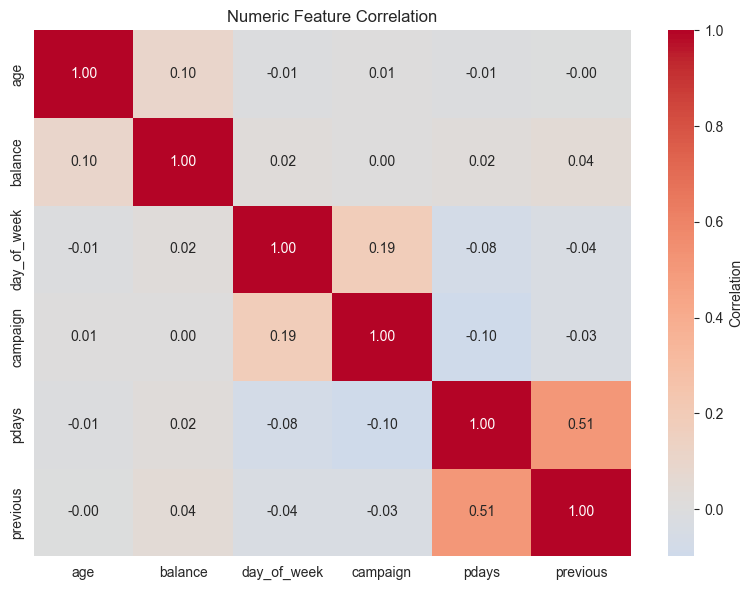

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(combined[numeric_cols].corr(), annot=True, cmap="coolwarm",
            center=0, fmt=".2f", cbar_kws={"label": "Correlation"})
plt.title("Numeric Feature Correlation")
plt.tight_layout()
plt.show()

## Preprocessing

In [5]:
y_bin     = (combined["y"] == "yes").astype(int).values
X_df      = combined.drop(columns=["y"])
X_encoded = pd.get_dummies(X_df, drop_first=True)

print(f"Encoded feature matrix shape: {X_encoded.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded.values.astype(float), y_bin,
    test_size=0.2, random_state=42,
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train size: {X_train_s.shape[0]}  |  Test size: {X_test_s.shape[0]}")
print(f"Train positive rate: {y_train.mean():.4f}")

Encoded feature matrix shape: (5000, 37)
Train size: 4000  |  Test size: 1000
Train positive rate: 0.1207


## Training

In [6]:
perc = Perceptron(learning_rate=0.01, n_epochs=200)
perc.fit(X_train_s, y_train)

train_acc = perc.score(X_train_s, y_train)
test_acc  = perc.score(X_test_s,  y_test)
print(f"Train accuracy: {train_acc:.4f}  |  Test accuracy: {test_acc:.4f}")

Train accuracy: 0.8698  |  Test accuracy: 0.8590


## Visualizations

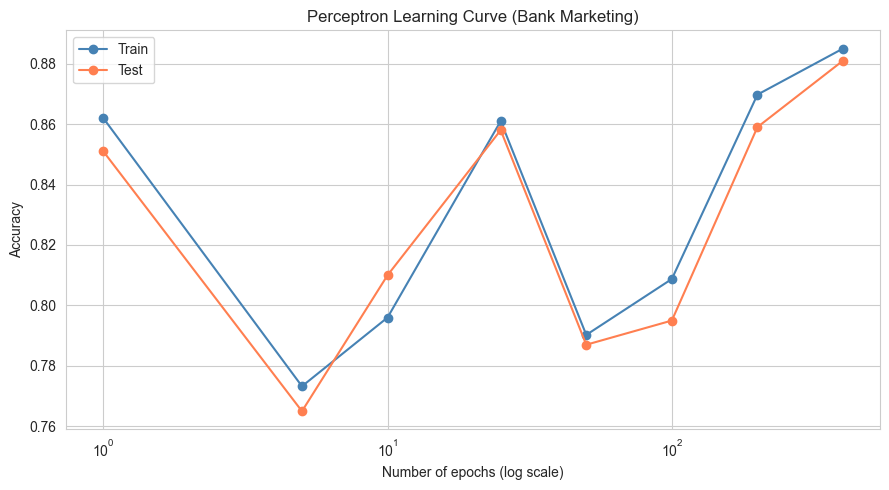

In [7]:
# Learning curve: refit at increasing epoch budgets and record test accuracy
epochs = [1, 5, 10, 25, 50, 100, 200, 400]
tr_curve, te_curve = [], []
for n in epochs:
    p = Perceptron(learning_rate=0.01, n_epochs=n).fit(X_train_s, y_train)
    tr_curve.append(p.score(X_train_s, y_train))
    te_curve.append(p.score(X_test_s,  y_test))

plt.figure(figsize=(9, 5))
plt.plot(epochs, tr_curve, marker="o", label="Train", color="steelblue")
plt.plot(epochs, te_curve, marker="o", label="Test",  color="coral")
plt.xscale("log")
plt.title("Perceptron Learning Curve (Bank Marketing)")
plt.xlabel("Number of epochs (log scale)")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

lr=0.001  Test acc: 0.8590  |  ||w||: 0.0271
lr=0.010  Test acc: 0.8590  |  ||w||: 0.2707
lr=0.100  Test acc: 0.8590  |  ||w||: 2.7066
lr=1.000  Test acc: 0.8590  |  ||w||: 27.0663


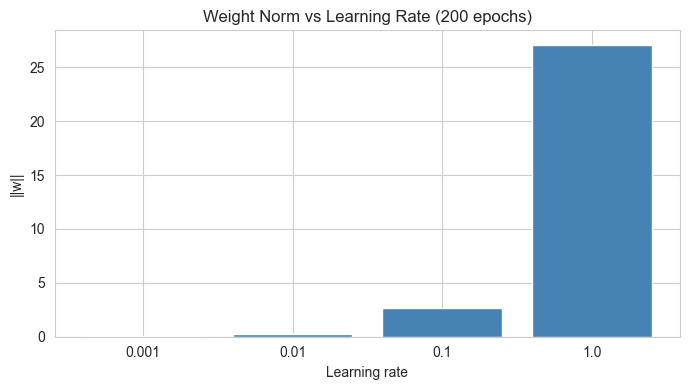

In [8]:
# Effect of learning rate
lrs = [0.001, 0.01, 0.1, 1.0]
for lr in lrs:
    p = Perceptron(learning_rate=lr, n_epochs=200).fit(X_train_s, y_train)
    norm = float(np.linalg.norm(p.coef_))
    te   = p.score(X_test_s, y_test)
    print(f"lr={lr:5.3f}  Test acc: {te:.4f}  |  ||w||: {norm:.4f}")

plt.figure(figsize=(7, 4))
norms     = [float(np.linalg.norm(Perceptron(learning_rate=lr, n_epochs=200)
                                  .fit(X_train_s, y_train).coef_)) for lr in lrs]
plt.bar([str(lr) for lr in lrs], norms, color="steelblue")
plt.title("Weight Norm vs Learning Rate (200 epochs)")
plt.xlabel("Learning rate")
plt.ylabel("||w||")
plt.tight_layout()
plt.show()

2D perceptron Train acc: 0.7827  |  Test acc: 0.7850


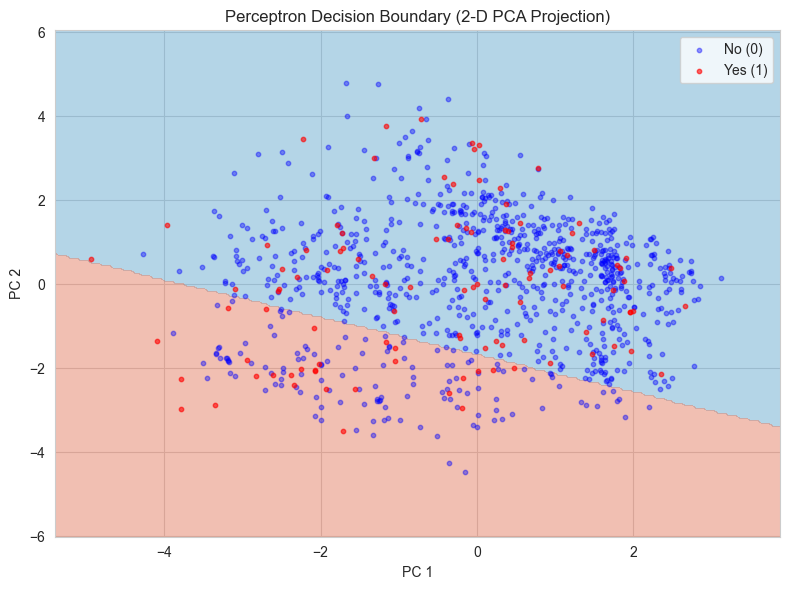

In [9]:
# 2-D PCA decision boundary
pca2 = PCA(n_components=2)
pca2.fit(X_train_s)
Z_train = pca2.transform(X_train_s)
Z_test  = pca2.transform(X_test_s)

p2d = Perceptron(learning_rate=0.01, n_epochs=200).fit(Z_train, y_train)
print(f"2D perceptron Train acc: {p2d.score(Z_train, y_train):.4f}  |  "
      f"Test acc: {p2d.score(Z_test, y_test):.4f}")

xx, yy = np.meshgrid(
    np.linspace(Z_train[:, 0].min() - 1, Z_train[:, 0].max() + 1, 200),
    np.linspace(Z_train[:, 1].min() - 1, Z_train[:, 1].max() + 1, 200),
)
grid    = np.c_[xx.ravel(), yy.ravel()]
zz      = p2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], cmap="RdBu_r", alpha=0.5)
plt.scatter(Z_test[y_test == 0, 0], Z_test[y_test == 0, 1], color="blue",
            s=10, alpha=0.4, label="No (0)")
plt.scatter(Z_test[y_test == 1, 0], Z_test[y_test == 1, 1], color="red",
            s=10, alpha=0.6, label="Yes (1)")
plt.title("Perceptron Decision Boundary (2-D PCA Projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Classification report on the held-out test set
y_pred = perc.predict(X_test_s)
classification_report(y_test, y_pred)

   class   precision      recall    f1-score   support
------------------------------------------------------
       0        0.91        0.94        0.92       890
       1        0.31        0.23        0.26       110
------------------------------------------------------
weighted avg        0.84        0.86        0.85      1000


## Interpretation and Conclusions

_Analysis to be completed after running the notebook end-to-end._